# Computer Lab 3: Modeling Planetary Temperature
This notebook will contain the code and write-ups for parts 1.1, 1.2, 1.3, 2.1, 2.2, and potentially 2.3 of the Planetary Climates computer lab. Parts 1.4 and 2.4 will be written up separately.

## Setup
As always, let's load some helpful packages. For this assignment, we will only need `numpy` and `matplotlib.pyplot`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Section 1: Radiative-Equilibrium Solutions
We begin with the first section of the assignment, **Radiative-Equilibrium Solutions**.

### Part 1.1
Part 1.1 asks us to use the equations discussed in class to compute Earth's temperature as a function of latitude, knowing that the latitude at which ice begins $y_i=0.95$. In radiative equilibrium, we know that $\frac{\partial T}{\partial t} = 0$. We also ignore oceanic-atmospheric effects at this step. This means that our temperature equation is governed by

$$ 0 = Q(1-\alpha(y))s(y)-(A+BT(y)) $$

which we can arrange to find

$$ T(y) = \frac{Q(1-\alpha(y))s(y)-A}{B} $$

Luckily, we already know a good amount of information about this equation. First, Legendre-polynomial fitting tells us that $s(y)\approx1.241-0.723y^2$. By fitting a first-order Taylor expansion to the Stefan-Boltzmann Law, we know that $A = 202 \frac{\mathrm{W}}{\mathrm{m}^2}$ and $B = 1.90 \frac{\mathrm{W}}{\degree\mathrm{C}\cdot\mathrm{m}^2}$. We also know that $Q$ is equal to a quarter of the solar constant, or $Q = 0.25\times1361 = 340.25$. Finally, $\alpha(y)$ is a piecewise constant function equal to $\alpha_-=0.32$ if $y\leq y_i$ and $\alpha_+=0.62$ if $y>y_i$. Thus, our equation becomes

$$ T(y) = \frac{340.25(1-(0.3\cdot\left\lceil{y-0.95}\right\rceil+0.32))(1.241-0.723y^2)-202}{1.90} $$

Let's define this function in Python, but for a vector of values $y$ --- this will let us plug in an entire linear space into the function later.


In [3]:
def T(y):
    alpha = 1 - (0.3 * np.ceil(y - 0.95) + 0.32)
    s = 1.241 - 0.723 * np.power(y, 2)
    numerator = 340.25 * alpha * s - 202
    return numerator / 1.90

Now, we are asked to plot this function. In class, we modeled only one hemisphere, so $y\in[0,1]$. We can use `numpy` and `matplotlib` to plot $T(y)$ over this range.

Text(0.5, 1.0, 'Latitudinal radiative-equilibrium temperature of the Earth')

<Figure size 640x480 with 0 Axes>

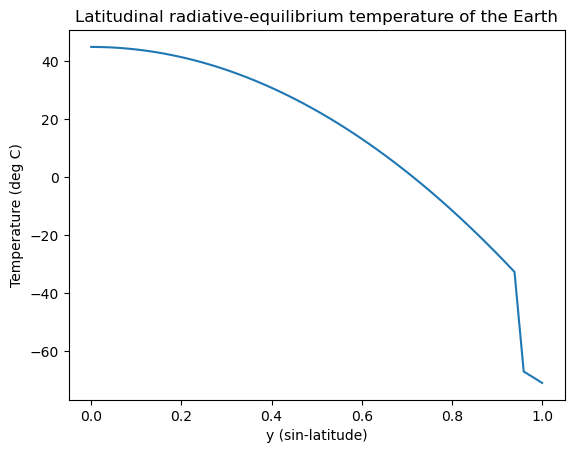

In [4]:
# Calculate function over linspace
y = np.linspace(0, 1)
res = T(y)

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
ax.plot(y, res)
ax.set_ylabel("Temperature (deg C)")
ax.set_xlabel("y (sin-latitude)")
ax.set_title("Latitudinal radiative-equilibrium temperature of the Earth")

While the shape of the "curve" may seem jarring at first, the jump at $y_i$ makes sense due to the piecewise nature of $\alpha(y)$. In addition, the values seem a bit extreme (over $40\degree\mathrm{C}$ at the equator is likely too hot on average) which makes sense, as we've removed the temperature regulation provided by the coupled oceanic-atmospheric system of the Earth.

### Part 1.2
<p style="color:red;font-size:48px">TODO</p>

### Part 1.3
To model the moon as a sphere in radiative equilibrium with an axial tilt of zero degrees, we must first figure out the geometric arrangement of the moon in relation to the Sun's rays. At latitude $\phi$, the orthogonal component of the Sun's rays to the moon's surface will have a magnitude of $S_{\odot}\cos(\phi)$. Since $\cos^2(\phi)+\sin^2(\phi)=1$, we know that $\cos(\phi)=\sqrt{1-y^2}$. Now, we must ensure that

$$\int_0^1s(y)dy=1\rightarrow\int_0^1k\sqrt{1-y^2}dy=1$$

for some constant $k$. We can thus evaluate this integral to find that 

$$\int_0^1\sqrt{1-y^2}dy=\frac{\pi}{4}$$

thus, $k=\frac{4}{\pi}$ and $s(y)=\frac{4}{\pi}\sqrt{1-y^2}$ for the moon. Let's plot this $s(y)$ against Earth's $s(y)$ from earlier.

Text(0.5, 1.0, 'Comparison of s(y) for Earth and the moon')

<Figure size 640x480 with 0 Axes>

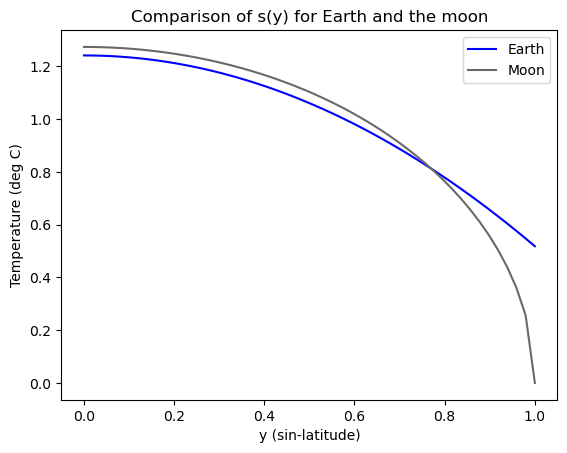

In [5]:
# Calculate s(y) funcs
s_earth = 1.241 - 0.723 * np.power(y, 2)
s_moon = 4/np.pi * np.sqrt(1 - np.power(y, 2))

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
ax.plot(y, s_earth, color = "blue", label = "Earth")
ax.plot(y, s_moon, color = "dimgray", label = "Moon")
ax.legend()
ax.set_xlabel("y (sin-latitude)")
ax.set_ylabel("Temperature (deg C)")
ax.set_title("Comparison of s(y) for Earth and the moon")

<p style="color:red">TODO: rest of 1.3</p>